# X-ray Structure Factor Visualization — 14GS

Visualises `r14gssf.ent` (mmCIF structure factor file).  
**Data available without phases**: amplitudes F, σ(F), Miller indices (h,k,l), R-free flags.

| Plot | What it shows |
|---|---|
| F/σ distribution | Data quality |
| Resolution shells | Completeness, mean F/σ vs d |
| Wilson plot | Overall B-factor (isotropic falloff) |
| Patterson v=0 | Inter-atomic vectors — Harker section for C1 2 1 |
| Reciprocal lattice | h-k plane coloured by F |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gemmi
from pathlib import Path

SF_FILE = Path("r14gssf.ent")   # relative to notebook/

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 1. Parse Structure Factor File

In [ ]:
doc   = gemmi.cif.read(str(SF_FILE))
block = doc.sole_block()

# ── Crystal metadata ───────────────────────────────────────────────────────
a   = float(block.find_value("_cell.length_a"))
b   = float(block.find_value("_cell.length_b"))
c   = float(block.find_value("_cell.length_c"))
alp = float(block.find_value("_cell.angle_alpha"))
bet = float(block.find_value("_cell.angle_beta"))
gam = float(block.find_value("_cell.angle_gamma"))
sg  = block.find_value("_symmetry.space_group_name_H-M").strip("'")
wl  = float(block.find_value("_diffrn_radiation_wavelength.wavelength"))

cell = gemmi.UnitCell(a, b, c, alp, bet, gam)
V    = cell.volume

print(f"Entry       : {block.find_value('_entry.id')}")
print(f"Space group : {sg}")
print(f"Unit cell   : a={a}  b={b}  c={c}  α={alp}  β={bet}  γ={gam}")
print(f"Volume      : {V:.1f} Å³")
print(f"Wavelength  : {wl} Å (Cu Kα)" if abs(wl - 1.5418) < 0.01 else f"Wavelength  : {wl} Å")

# ── Reflections ───────────────────────────────────────────────────────────
rfl = block.find("_refln.",
                 ["index_h", "index_k", "index_l",
                  "status", "F_meas_au", "F_meas_sigma_au"])

h      = np.array([int(r[0])   for r in rfl])
k      = np.array([int(r[1])   for r in rfl])
l      = np.array([int(r[2])   for r in rfl])
status = np.array([r[3]        for r in rfl])   # 'o' = working, 'f' = R-free
F      = np.array([float(r[4]) for r in rfl])
sigF   = np.array([float(r[5]) for r in rfl])

# Resolution d = 1 / |s| for each reflection
d = np.array([cell.calculate_d([h[i], k[i], l[i]]) for i in range(len(h))])

n_work = (status == "o").sum()
n_free = (status == "f").sum()
print(f"\nReflections : {len(h):,} total  ({n_work:,} working + {n_free:,} R-free)")
print(f"Resolution  : {d.max():.1f} – {d.min():.2f} Å")

Entry       : 14gs
Space group : C 1 2 1
Unit cell   : a=78.651  b=91.826  c=69.143  α=90.0  β=98.25  γ=90.0
Volume      : 494197.3 Å³
Wavelength  : 1.5418 Å (Cu Kα)

Reflections : 10,287 total  (9,746 working + 541 R-free)
Resolution  : 8.0 – 2.80 Å


## 2. F/σ Distribution

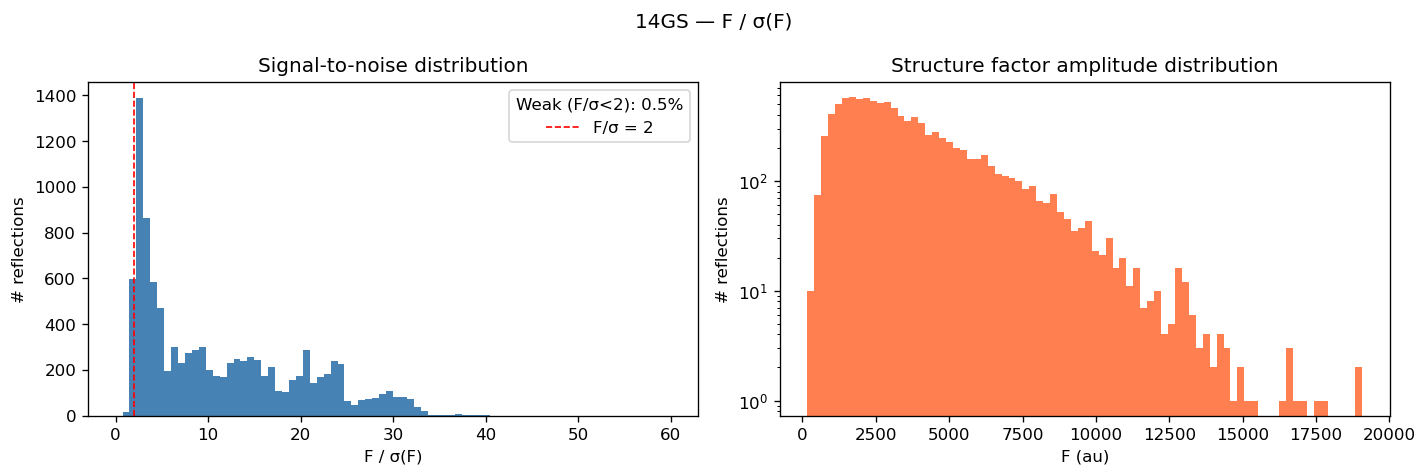

Mean F/σ : 11.4   Median F/σ : 8.8
Weak reflections (F/σ < 2) : 55 / 10,287  (0.5%)


In [ ]:
FoS = F / sigF

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# F/σ histogram
ax = axes[0]
ax.hist(FoS, bins=80, range=(0, 60), color="steelblue", edgecolor="none")
ax.axvline(2, color="red", ls="--", lw=1, label="F/σ = 2")
ax.set_xlabel("F / σ(F)")
ax.set_ylabel("# reflections")
ax.set_title("Signal-to-noise distribution")
weak = (FoS < 2).sum()
ax.legend(title=f"Weak (F/σ<2): {weak/len(FoS)*100:.1f}%")

# F histogram (log scale)
ax = axes[1]
ax.hist(F, bins=80, color="coral", edgecolor="none")
ax.set_xlabel("F (au)")
ax.set_ylabel("# reflections")
ax.set_title("Structure factor amplitude distribution")
ax.set_yscale("log")

plt.suptitle("14GS — F / σ(F)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Mean F/σ : {FoS.mean():.1f}   Median F/σ : {np.median(FoS):.1f}")
print(f"Weak reflections (F/σ < 2) : {weak:,} / {len(FoS):,}  ({weak/len(FoS)*100:.1f}%)")

## 3. Resolution Shell Statistics

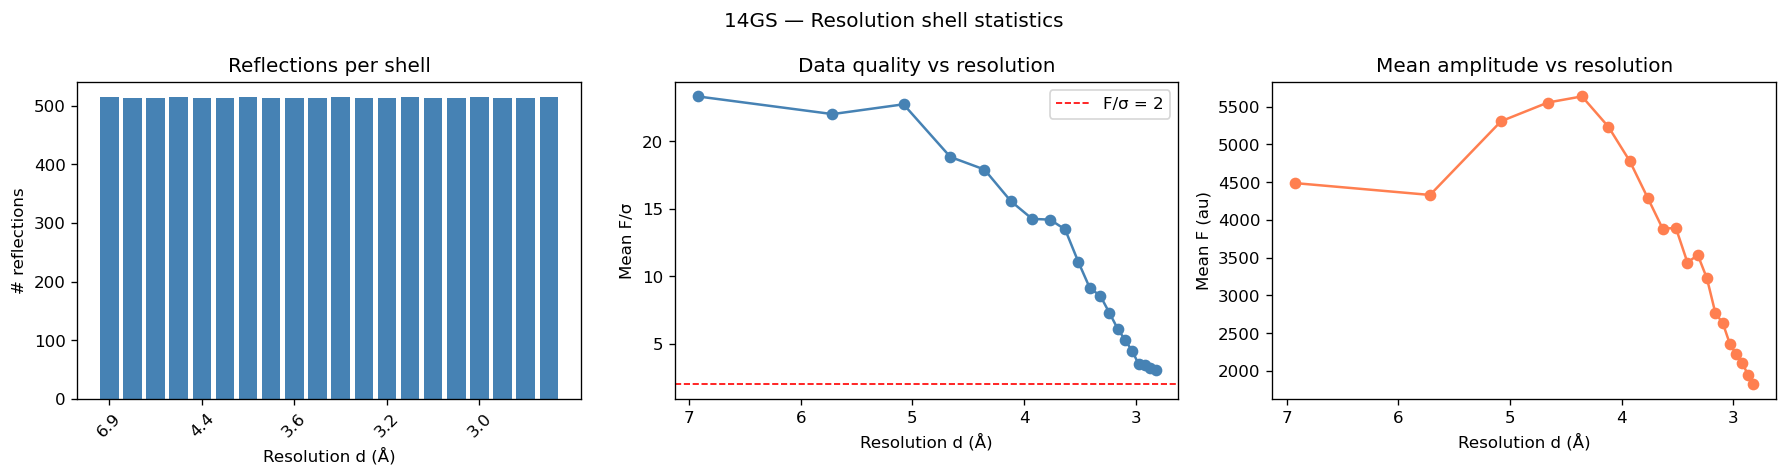

In [ ]:
N_SHELLS = 20

# Bin by 1/d² (uniform in sin²θ/λ² space)
inv_d2     = (1 / d) ** 2
shell_edges = np.percentile(inv_d2, np.linspace(0, 100, N_SHELLS + 1))
shell_idx   = np.digitize(inv_d2, shell_edges) - 1
shell_idx   = np.clip(shell_idx, 0, N_SHELLS - 1)

d_mid, n_shell, mean_FoS, mean_F = [], [], [], []

for i in range(N_SHELLS):
    m = shell_idx == i
    if m.sum() == 0:
        continue
    d_mid.append(d[m].mean())
    n_shell.append(m.sum())
    mean_FoS.append(FoS[m].mean())
    mean_F.append(F[m].mean())

d_mid    = np.array(d_mid)
n_shell  = np.array(n_shell)
mean_FoS = np.array(mean_FoS)
mean_F   = np.array(mean_F)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(range(len(d_mid)), n_shell, color="steelblue")
axes[0].set_xticks(range(0, len(d_mid), 4))
axes[0].set_xticklabels([f"{d_mid[i]:.1f}" for i in range(0, len(d_mid), 4)], rotation=45)
axes[0].set_xlabel("Resolution d (Å)")
axes[0].set_ylabel("# reflections")
axes[0].set_title("Reflections per shell")

axes[1].plot(d_mid, mean_FoS, "o-", color="steelblue")
axes[1].axhline(2, color="red", ls="--", lw=1, label="F/σ = 2")
axes[1].set_xlabel("Resolution d (Å)")
axes[1].set_ylabel("Mean F/σ")
axes[1].set_title("Data quality vs resolution")
axes[1].legend()
axes[1].invert_xaxis()

axes[2].plot(d_mid, mean_F, "o-", color="coral")
axes[2].set_xlabel("Resolution d (Å)")
axes[2].set_ylabel("Mean F (au)")
axes[2].set_title("Mean amplitude vs resolution")
axes[2].invert_xaxis()

plt.suptitle("14GS — Resolution shell statistics", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Wilson Plot

ln(⟨F²⟩) vs sin²θ/λ² should be linear: slope = −2B, intercept = ln(C)  
Gives the overall isotropic B-factor (thermal motion / disorder).

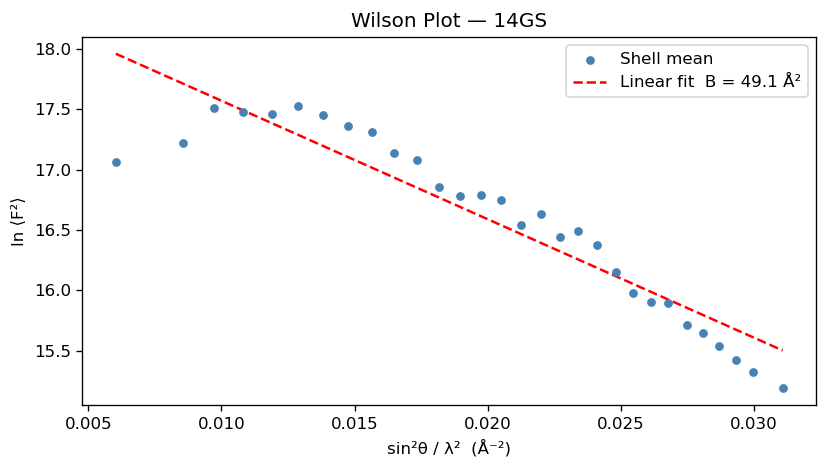

Overall Wilson B-factor : 49.1 Å²


In [ ]:
sin2_over_lam2 = (1 / (2 * d)) ** 2   # sin²θ/λ² = 1/(4d²)

# Bin and compute mean ln(F²) per shell
N_W = 30
edges_w  = np.percentile(sin2_over_lam2, np.linspace(5, 95, N_W + 1))
idx_w    = np.digitize(sin2_over_lam2, edges_w) - 1
idx_w    = np.clip(idx_w, 0, N_W - 1)

xs, ys = [], []
for i in range(N_W):
    m = idx_w == i
    if m.sum() < 5:
        continue
    f2 = (F[m] ** 2)
    xs.append(sin2_over_lam2[m].mean())
    ys.append(np.log(f2.mean()))

xs, ys = np.array(xs), np.array(ys)

# Linear fit
coeffs   = np.polyfit(xs, ys, 1)
B_wilson = -coeffs[0] / 2
fit_line = np.poly1d(coeffs)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(xs, ys, s=18, color="steelblue", zorder=3, label="Shell mean")
x_fit = np.linspace(xs.min(), xs.max(), 100)
ax.plot(x_fit, fit_line(x_fit), "r--", lw=1.5,
        label=f"Linear fit  B = {B_wilson:.1f} Å²")
ax.set_xlabel("sin²θ / λ²  (Å⁻²)")
ax.set_ylabel("ln ⟨F²⟩")
ax.set_title("Wilson Plot — 14GS")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Overall Wilson B-factor : {B_wilson:.1f} Å²")

## 5. Patterson Map — v = 0 Harker Section

Patterson function P(u,v,w) = FT{ |F(hkl)|² }. No phases needed.  
For space group **C 1 2 1** (2-fold along b), the **v = 0** section (Harker section)  
contains peaks at (2x, 0, 2z) for every pair of atoms related by the 2-fold axis.

Patterson grid: 64 × 128 × 64


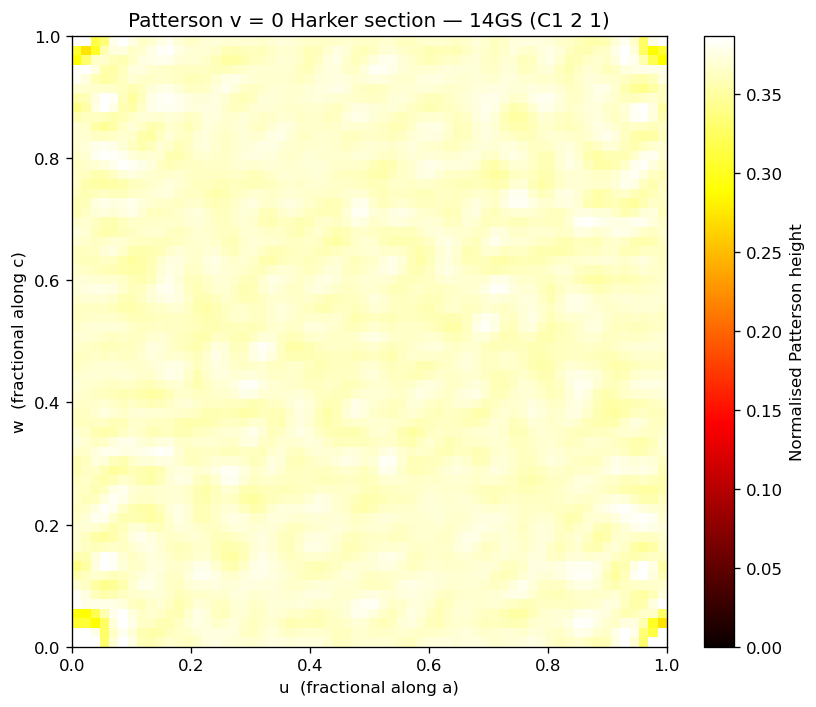

In [ ]:
# Grid dimensions: oversample by 2× for smooth appearance
hmax = int(h.max())
kmax = int(k.max())
lmax = int(l.max())

# Choose grid size ≥ 2× max index + 1, padded to next power-of-2 for FFT speed
def next_pow2(n): return 1 << (n - 1).bit_length()

NX = next_pow2(2 * hmax + 2)
NY = next_pow2(2 * kmax + 2)
NZ = next_pow2(2 * lmax + 2)
print(f"Patterson grid: {NX} × {NY} × {NZ}")

# Build |F|² at each reciprocal lattice point (+ Friedel mates)
F2grid = np.zeros((NX, NY, NZ), dtype=np.float64)

for i in range(len(h)):
    F2 = F[i] ** 2
    # (h, k, l)
    F2grid[h[i] % NX, k[i] % NY, l[i] % NZ] += F2
    # Friedel mate (-h, -k, -l)
    F2grid[(-h[i]) % NX, (-k[i]) % NY, (-l[i]) % NZ] += F2

# IFFT → Patterson map (real-valued)
patterson = np.real(np.fft.ifftn(F2grid))
# Normalise to [0, 1]
patterson -= patterson.min()
patterson /= patterson.max()

# ── v = 0 Harker section (k-index = 0 in the FFT grid) ──────────────────
v0 = patterson[:, 0, :].T   # (NZ, NX) → transpose so u runs right, w runs up

# Fractional coordinates along u and w
u_ax = np.linspace(0, 1, NX, endpoint=False)
w_ax = np.linspace(0, 1, NZ, endpoint=False)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    v0,
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="hot",
    aspect="auto",
    vmin=0,
    vmax=np.percentile(v0, 99.5),
)
plt.colorbar(im, ax=ax, label="Normalised Patterson height")
ax.set_xlabel("u  (fractional along a)")
ax.set_ylabel("w  (fractional along c)")
ax.set_title("Patterson v = 0 Harker section — 14GS (C1 2 1)")
plt.tight_layout()
plt.show()

## 6. Reciprocal Lattice — h-k Plane

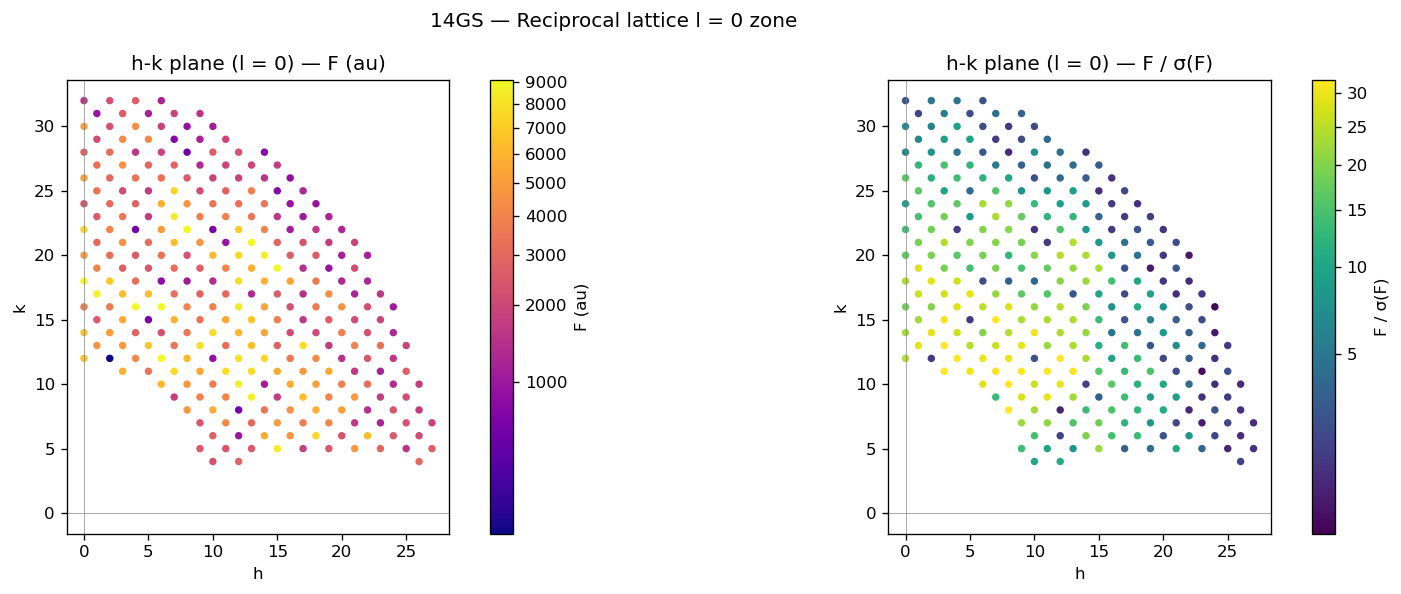

C-centering check (l=0 zone):
  h+k even (allowed) :  283 reflections  mean F = 3601.4
  h+k odd  (absent)  :    0 reflections  mean F = nan


/tmp/ipykernel_292105/4023620816.py:31: RuntimeWarning: Mean of empty slice
  print(f"  h+k odd  (absent)  : {odd_hk.sum():4d} reflections  mean F = {F[odd_hk].mean():.1f}")
/home/shpark/miniforge3/envs/voxbind/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# Show only l = 0 layer (strongest zone)
mask_l0  = l == 0
h0, k0   = h[mask_l0], k[mask_l0]
F0, FoS0 = F[mask_l0], FoS[mask_l0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, vals, label, cmap in [
    (axes[0], F0,   "F (au)",  "plasma"),
    (axes[1], FoS0, "F / σ(F)","viridis"),
]:
    sc = ax.scatter(h0, k0, c=vals, cmap=cmap, s=12,
                   norm=mcolors.PowerNorm(gamma=0.4, vmin=vals.min(), vmax=np.percentile(vals, 98)))
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_xlabel("h")
    ax.set_ylabel("k")
    ax.set_title(f"h-k plane (l = 0) — {label}")
    ax.set_aspect("equal")
    ax.axhline(0, lw=0.4, color="gray")
    ax.axvline(0, lw=0.4, color="gray")

plt.suptitle("14GS — Reciprocal lattice l = 0 zone", fontsize=12)
plt.tight_layout()
plt.show()

# C-centering check: h+k odd should be absent
odd_hk  = mask_l0 & ((h + k) % 2 == 1)
even_hk = mask_l0 & ((h + k) % 2 == 0)
print(f"C-centering check (l=0 zone):")
print(f"  h+k even (allowed) : {even_hk.sum():4d} reflections  mean F = {F[even_hk].mean():.1f}")
print(f"  h+k odd  (absent)  : {odd_hk.sum():4d} reflections  mean F = {F[odd_hk].mean():.1f}")